In [1]:
import requests

In [2]:
import json

In [3]:
import os

In [4]:
# pip install pandas

In [5]:
import pandas as pd

In [6]:
# %pip install matplotlib

In [7]:
# %pip install scipy

In [8]:
# %pip install numpy pandas matplotlib scipy scikit-learn

In [9]:
# save StatsBomb match data as "passing_2023.json"

In [10]:
url = "https://raw.githubusercontent.com/statsbomb/open-data/refs/heads/master/data/matches/72/107.json"

response = requests.get(url)

with open("passing_2023.json", "wb") as f:
    f.write(response.content)

In [11]:
# print out all 64 match ids

In [12]:
with open("passing_2023.json", "r", encoding="utf-8") as f:
    data = json.load(f)

In [13]:
for match in data:
    print(match["match_id"])

3893834
3893808
3893818
3893795
3893825
3893798
3893832
3893829
3893805
3901734
3893802
3893799
3893824
3893827
3893819
3893815
3893800
3893816
3893830
3893833
3901833
3901736
3902968
3893793
3893826
3893823
3893813
3893790
3893796
3893831
3906390
3893804
3893791
3901733
3893810
3893787
3893820
3893817
3904629
3906389
3893821
3904628
3893806
3893801
3893797
3893822
3893814
3901832
3902967
3901797
3901796
3902240
3902239
3901735
3893811
3893812
3893809
3893807
3893788
3893789
3893794
3893792
3893828
3893803


In [14]:
match_ids = [match["match_id"] for match in data]
print(match_ids)

[3893834, 3893808, 3893818, 3893795, 3893825, 3893798, 3893832, 3893829, 3893805, 3901734, 3893802, 3893799, 3893824, 3893827, 3893819, 3893815, 3893800, 3893816, 3893830, 3893833, 3901833, 3901736, 3902968, 3893793, 3893826, 3893823, 3893813, 3893790, 3893796, 3893831, 3906390, 3893804, 3893791, 3901733, 3893810, 3893787, 3893820, 3893817, 3904629, 3906389, 3893821, 3904628, 3893806, 3893801, 3893797, 3893822, 3893814, 3901832, 3902967, 3901797, 3901796, 3902240, 3902239, 3901735, 3893811, 3893812, 3893809, 3893807, 3893788, 3893789, 3893794, 3893792, 3893828, 3893803]


In [15]:
# save 64 individual game data

In [16]:
with open("passing_2023.json", "r", encoding="utf-8") as f:
    matches = json.load(f)

match_ids = [m["match_id"] for m in matches]

In [17]:
os.makedirs("events", exist_ok=True)

base_url = "https://raw.githubusercontent.com/statsbomb/open-data/refs/heads/master/data/events/"

match_ids = sorted(match_ids)

for match_id in match_ids:
    url = f"{base_url}{match_id}.json"
    
    response = requests.get(url, timeout=30)
    
    file_path = f"events/{match_id}.json"
    
    with open(file_path, "wb") as f:
        f.write(response.content)
    
    print(f"Saved {file_path}")

Saved events/3893787.json
Saved events/3893788.json
Saved events/3893789.json
Saved events/3893790.json
Saved events/3893791.json
Saved events/3893792.json
Saved events/3893793.json
Saved events/3893794.json
Saved events/3893795.json
Saved events/3893796.json
Saved events/3893797.json
Saved events/3893798.json
Saved events/3893799.json
Saved events/3893800.json
Saved events/3893801.json
Saved events/3893802.json
Saved events/3893803.json
Saved events/3893804.json
Saved events/3893805.json
Saved events/3893806.json
Saved events/3893807.json
Saved events/3893808.json
Saved events/3893809.json
Saved events/3893810.json
Saved events/3893811.json
Saved events/3893812.json
Saved events/3893813.json
Saved events/3893814.json
Saved events/3893815.json
Saved events/3893816.json
Saved events/3893817.json
Saved events/3893818.json
Saved events/3893819.json
Saved events/3893820.json
Saved events/3893821.json
Saved events/3893822.json
Saved events/3893823.json
Saved events/3893824.json
Saved events

In [18]:
# save unique match ids for each country as "[country name] Women's"

In [19]:
with open("passing_2023.json", "r", encoding="utf-8") as f:
    matches = json.load(f)

In [20]:
team_match_ids = {}

In [21]:
def get_match_ids(team_name, matches):
    return sorted([
        m["match_id"]
        for m in matches
        if m.get("home_team", {}).get("home_team_name") == team_name
        or m.get("away_team", {}).get("away_team_name") == team_name
    ])

In [22]:
for m in matches:
    home = m.get("home_team", {}).get("home_team_name")
    away = m.get("away_team", {}).get("away_team_name")
    
    if home and home not in team_match_ids:
        team_match_ids[home] = get_match_ids(home, matches)
    
    if away and away not in team_match_ids:
        team_match_ids[away] = get_match_ids(away, matches)

In [23]:
print(sorted(team_match_ids.keys()))

["Argentina Women's", "Australia Women's", "Brazil Women's", "Canada Women's", "China PR Women's", "Colombia Women's", "Costa Rica Women's", "Denmark Women's", "England Women's", "France Women's", "Germany Women's", "Haiti Women's", "Italy Women's", "Jamaica Women's", "Japan Women's", "Korea Republic Women's", "Morocco Women's", "Netherlands Women's", "New Zealand Women's", "Nigeria Women's", "Norway Women's", "Panama Women's", "Philippines Women's", "Portugal Women's", "Republic of Ireland Women's", "South Africa Women's", "Spain Women's", "Sweden Women's", "Switzerland Women's", "United States Women's", "Vietnam Women's", 'Zambia W']


In [24]:
for team, ids in sorted(team_match_ids.items()):
    print("===================================")
    print(team)
    print(ids)

Argentina Women's
[3893800, 3893812, 3893830]
Australia Women's
[3893788, 3893809, 3893821, 3901736, 3902968, 3904629, 3906389]
Brazil Women's
[3893801, 3893815, 3893832]
Canada Women's
[3893790, 3893807, 3893821]
China PR Women's
[3893795, 3893813, 3893828]
Colombia Women's
[3893802, 3893818, 3893834, 3901832, 3902967]
Costa Rica Women's
[3893791, 3893805, 3893823]
Denmark Women's
[3893795, 3893811, 3893825, 3901736]
England Women's
[3893794, 3893811, 3893828, 3901735, 3902967, 3904629, 3906390]
France Women's
[3893798, 3893815, 3893829, 3901833, 3902968]
Germany Women's
[3893799, 3893818, 3893833]
Haiti Women's
[3893794, 3893813, 3893825]
Italy Women's
[3893800, 3893814, 3893831]
Jamaica Women's
[3893798, 3893816, 3893832, 3901832]
Japan Women's
[3893793, 3893805, 3893822, 3901734, 3902239]
Korea Republic Women's
[3893802, 3893819, 3893833]
Morocco Women's
[3893799, 3893819, 3893834, 3901833]
Netherlands Women's
[3893797, 3893808, 3893827, 3901796, 3902240]
New Zealand Women's
[38937

In [25]:
# create all 32 tables of data (total, ground, low, high, air passes)

In [75]:
def build_team_table(team_name, match_ids):

    match_ids = sorted(match_ids)
    rows = []

    for game_number, match_id in enumerate(match_ids, start=1):

        with open(f"events/{match_id}.json", "r", encoding="utf-8") as f:
            data = json.load(f)

        passes = [
            e for e in data
            if e.get("type", {}).get("name") == "Pass"
            and e.get("team", {}).get("name") == team_name
        ]

        completed = [
            p for p in passes
            if p.get("pass", {}).get("outcome") is None
        ]

        ground = [
            p for p in passes
            if p.get("pass", {}).get("height", {}).get("name") == "Ground Pass"
        ]

        low = [
            p for p in passes
            if p.get("pass", {}).get("height", {}).get("name") == "Low Pass"
        ]

        high = [
            p for p in passes
            if p.get("pass", {}).get("height", {}).get("name") == "High Pass"
        ]

        air = [
            p for p in passes
            if p.get("pass", {}).get("height", {}).get("name") == "Air Pass"
        ]

        def pct(comp, total):
            return round(comp / total * 100, 1) if total > 0 else 0

        rows.append({
            "match_id": match_id,
            "game_number": game_number,

            "total_passes": len(passes),
            "completed_passes": len(completed),
            "completion_%": pct(len(completed), len(passes)),

            "ground_total": len(ground),
            "ground_completed": sum(1 for p in ground if p.get("pass", {}).get("outcome") is None),
            "ground_%": pct(
                sum(1 for p in ground if p.get("pass", {}).get("outcome") is None),
                len(ground)
            ),

            "low_total": len(low),
            "low_completed": sum(1 for p in low if p.get("pass", {}).get("outcome") is None),
            "low_%": pct(
                sum(1 for p in low if p.get("pass", {}).get("outcome") is None),
                len(low)
            ),

            "high_total": len(high),
            "high_completed": sum(1 for p in high if p.get("pass", {}).get("outcome") is None),
            "high_%": pct(
                sum(1 for p in high if p.get("pass", {}).get("outcome") is None),
                len(high)
            ),

            "air_total": len(low) + len(high),
            "air_completed": 
                sum(1 for p in low if p.get("pass", {}).get("outcome") is None) 
                + sum(1 for p in high if p.get("pass", {}).get("outcome") is None),
            "air_%": pct(
                sum(1 for p in low if p.get("pass", {}).get("outcome") is None)
                + sum(1 for p in high if p.get("pass", {}).get("outcome") is None),
                len(low) + len(high)
            )
        })

    df = pd.DataFrame(rows)

    df = df.sort_values("match_id").reset_index(drop=True)
    
    avg = df.drop(columns=["match_id", "game_number"]).mean(numeric_only=True)

    totals = df.sum(numeric_only=True)
    
    avg_row = {
        "match_id": "AVERAGE",
        "game_number": "",

        "total_passes": avg["total_passes"],
        "completed_passes": avg["completed_passes"],
        "completion_%": totals["completed_passes"] / totals["total_passes"] * 100,

        "ground_total": avg["ground_total"],
        "ground_completed": avg["ground_completed"],
        "ground_%": totals["ground_completed"] / totals["ground_total"] * 100,
    
        "low_total": avg["low_total"],
        "low_completed": avg["low_completed"],
        "low_%": totals["low_completed"] / totals["low_total"] * 100,

        "high_total": avg["high_total"],
        "high_completed": avg["high_completed"],
        "high_%": totals["high_completed"] / totals["high_total"] * 100,

        "air_total": avg["air_total"],
        "air_completed": avg["air_completed"],
        "air_%": totals["air_completed"] / totals["air_total"] * 100
    }

    df = pd.concat([df, pd.DataFrame([avg_row])], ignore_index=True)

    df.index = range(1, len(df) + 1)

    return df

In [76]:
def highlight_average_row(row):
    if row["match_id"] == "AVERAGE":
        return ["background-color: #f0f0f0; font-weight: bold;"] * len(row)
    return [""] * len(row)

In [77]:
from IPython.display import display

def show_table(team_name):
    df = tables[team_name]
    
    print("======================================")
    print(team_name.upper())
    print("======================================")
    display(df)

In [78]:
tables = {}

for team_name, match_ids in team_match_ids.items():

    team_key = team_name.replace(" Women's", "").replace(" W", "")
    var_name = team_key.lower().replace(" ", "_") + "_df"

    df = build_team_table(team_name, match_ids)

    globals()[var_name] = df

    tables[team_name] = df

    print("Created:", var_name)

Created: morocco_df
Created: colombia_df
Created: united_states_df
Created: netherlands_df
Created: germany_df
Created: denmark_df
Created: china_pr_df
Created: haiti_df
Created: france_df
Created: jamaica_df
Created: brazil_df
Created: panama_df
Created: japan_df
Created: costa_rica_df
Created: norway_df
Created: korea_republic_df
Created: republic_of_ireland_df
Created: nigeria_df
Created: vietnam_df
Created: italy_df
Created: argentina_df
Created: sweden_df
Created: australia_df
Created: zambia_df
Created: portugal_df
Created: canada_df
Created: south_africa_df
Created: spain_df
Created: england_df
Created: switzerland_df
Created: new_zealand_df
Created: philippines_df


In [79]:
# print 32 tables

In [80]:
for team_name in sorted(tables.keys()):
    
    print("======================================")
    print(team_name.upper())
    print("======================================")
    
    display(tables[team_name])

ARGENTINA WOMEN'S


,match_id,game_number,total_passes,completed_passes,completion_%,ground_total,ground_completed,ground_%,low_total,low_completed,low_%,high_total,high_completed,high_%,air_total,air_completed,air_%
1,3893800,1,388.0,279.000000,71.900000,224.000000,196.000000,87.500000,62.0,34.000000,54.800000,102.000000,49.0,48.000000,164.000000,83.000000,50.600000
2,3893812,2,553.0,418.000000,75.600000,321.000000,283.000000,88.200000,95.0,61.000000,64.200000,137.000000,74.0,54.000000,232.000000,135.000000,58.200000
3,3893830,3,352.0,246.000000,69.900000,198.000000,168.000000,84.800000,62.0,39.000000,62.900000,92.000000,39.0,42.400000,154.000000,78.000000,50.600000
4,AVERAGE,,431.0,314.333333,72.931168,247.666667,215.666667,87.079408,73.0,44.666667,61.187215,110.333333,54.0,48.942598,183.333333,98.666667,53.818182


AUSTRALIA WOMEN'S


,match_id,game_number,total_passes,completed_passes,completion_%,ground_total,ground_completed,ground_%,low_total,low_completed,low_%,high_total,high_completed,high_%,air_total,air_completed,air_%
1,3893788,1,491.000000,397.000000,80.900000,366.000000,335.000000,91.500000,46.000000,31.000000,67.400000,79.000000,31.000000,39.200000,125.0,62.0,49.60000
2,3893809,2,518.000000,391.000000,75.500000,349.000000,318.000000,91.100000,64.000000,39.000000,60.900000,105.000000,34.000000,32.400000,169.0,73.0,43.20000
3,3893821,3,370.000000,229.000000,61.900000,191.000000,159.000000,83.200000,70.000000,31.000000,44.300000,109.000000,39.000000,35.800000,179.0,70.0,39.10000
4,3901736,4,416.000000,289.000000,69.500000,248.000000,226.000000,91.100000,69.000000,36.000000,52.200000,99.000000,27.000000,27.300000,168.0,63.0,37.50000
5,3902968,5,505.000000,342.000000,67.700000,271.000000,231.000000,85.200000,77.000000,52.000000,67.500000,157.000000,59.000000,37.600000,234.0,111.0,47.40000
6,3904629,6,389.000000,279.000000,71.700000,219.000000,202.000000,92.200000,59.000000,37.000000,62.700000,111.000000,40.000000,36.000000,170.0,77.0,45.30000
7,3906389,7,418.000000,284.000000,67.900000,217.000000,180.000000,82.900000,58.000000,37.000000,63.800000,143.000000,67.000000,46.900000,201.0,104.0,51.70000
8,AVERAGE,,443.857143,315.857143,71.161893,265.857143,235.857143,88.715744,63.285714,37.571429,59.367946,114.714286,42.428571,36.986301,178.0,80.0,44.94382


BRAZIL WOMEN'S


...

,match_id,game_number,total_passes,completed_passes,completion_%,ground_total,ground_completed,ground_%,low_total,low_completed,low_%,high_total,high_completed,high_%,air_total,air_completed,air_%
1,3893792,1,543.0,406.00,74.800000,344.00,302.00,87.800000,92.00,55.0,59.800000,107.0,49.0,45.800000,199.00,104.0,52.300000
2,3893808,2,419.0,285.00,68.000000,229.00,187.00,81.700000,74.00,41.0,55.400000,116.0,57.0,49.100000,190.00,98.0,51.600000
3,3893826,3,333.0,218.00,65.500000,162.00,130.00,80.200000,63.00,34.0,54.000000,108.0,54.0,50.000000,171.00,88.0,51.500000
4,3901797,4,667.0,500.00,75.000000,408.00,368.00,90.200000,96.00,64.0,66.700000,163.0,68.0,41.700000,259.00,132.0,51.000000
5,AVERAGE,,490.5,352.25,71.814475,285.75,246.75,86.351706,81.25,48.5,59.692308,123.5,57.0,46.153846,204.75,105.5,51.526252


VIETNAM WOMEN'S


,match_id,game_number,total_passes,completed_passes,completion_%,ground_total,ground_completed,ground_%,low_total,low_completed,low_%,high_total,high_completed,high_%,air_total,air_completed,air_%
1,3893792,1,281.0,148.0,52.700000,120.0,96.000000,80.000000,49.0,24.000000,49.00000,112.0,28.0,25.000000,161.0,52.000000,32.300000
2,3893810,2,284.0,166.0,58.500000,123.0,96.000000,78.000000,63.0,33.000000,52.40000,98.0,37.0,37.800000,161.0,70.000000,43.500000
3,3893827,3,326.0,205.0,62.900000,156.0,125.000000,80.100000,65.0,40.000000,61.50000,105.0,40.0,38.100000,170.0,80.000000,47.100000
4,AVERAGE,,297.0,173.0,58.249158,133.0,105.666667,79.448622,59.0,32.333333,54.80226,105.0,35.0,33.333333,164.0,67.333333,41.056911


ZAMBIA W


,match_id,game_number,total_passes,completed_passes,completion_%,ground_total,ground_completed,ground_%,low_total,low_completed,low_%,high_total,high_completed,high_%,air_total,air_completed,air_%
1,3893793,1,455.000000,312.000000,68.600000,258.000000,233.000000,90.30000,80.000000,40.0,50.00000,117.000000,39.0,33.300000,197.0,79.0,40.100000
2,3893806,2,281.000000,164.000000,58.400000,136.000000,104.000000,76.50000,47.000000,28.0,59.60000,98.000000,32.0,32.700000,145.0,60.0,41.400000
3,3893823,3,325.000000,198.000000,60.900000,169.000000,133.000000,78.70000,67.000000,34.0,50.70000,89.000000,31.0,34.800000,156.0,65.0,41.700000
4,AVERAGE,,353.666667,224.666667,63.524976,187.666667,156.666667,83.48135,64.666667,34.0,52.57732,101.333333,34.0,33.552632,166.0,68.0,40.963855


In [81]:
# create averages comparison table

In [82]:
with open("passing_2023.json", "r", encoding="utf-8") as f:
    matches = json.load(f)

In [83]:
team_match_ids = {}

for m in matches:
    home = m.get("home_team", {}).get("home_team_name")
    away = m.get("away_team", {}).get("away_team_name")

    for team in [home, away]:
        if team:
            team_match_ids.setdefault(team, []).append(m["match_id"])

In [100]:
def build_team_table(team_name, match_ids):

    rows = []

    for i, match_id in enumerate(sorted(match_ids), start=1):

        with open(f"events/{match_id}.json", "r", encoding="utf-8") as f:
            data = json.load(f)

        passes = [
            e for e in data
            if e.get("type", {}).get("name") == "Pass"
            and e.get("team", {}).get("name") == team_name
        ]

        completed = [
            p for p in passes
            if p.get("pass", {}).get("outcome") is None
        ]

        ground = [
            p for p in passes
            if p.get("pass", {}).get("height", {}).get("name") == "Ground Pass"
        ]

        low = [
            p for p in passes
            if p.get("pass", {}).get("height", {}).get("name") == "Low Pass"
        ]

        high = [
            p for p in passes
            if p.get("pass", {}).get("height", {}).get("name") == "High Pass"
        ]

        air = [
            p for p in passes
            if p.get("pass", {}).get("height", {}).get("name") == "Air Pass"
        ]

        
        def pct(a, b):
            return round(a / b * 100, 1) if b else 0

        rows.append({
            "match_id": match_id,
            "game_number": i,

            "total_passes": len(passes),
            "completed_passes": len(completed),
            "completion_%": pct(len(completed), len(passes)),

            "ground_total": len(ground),
            "ground_completed": sum(
                1 for p in ground if p.get("pass", {}).get("outcome") is None),
            "ground_%": pct(
                sum(1 for p in ground if p.get("pass", {}).get("outcome") is None),
                len(ground)),

            "low_total": len(low),
            "low_completed": sum(
                1 for p in low if p.get("pass", {}).get("outcome") is None),
            "low_%": pct(
                sum(1 for p in low if p.get("pass", {}).get("outcome") is None),
                len(low)),

            "high_total": len(high),
            "high_completed": sum(
                1 for p in high if p.get("pass", {}).get("outcome") is None),
            "high_%": pct(
                sum(1 for p in high if p.get("pass", {}).get("outcome") is None),
                len(high)),

            "air_total": len(low) + len(high),
            "air_completed": 
                sum(1 for p in low if p.get("pass", {}).get("outcome") is None) 
                + sum(1 for p in high if p.get("pass", {}).get("outcome") is None),
            "air_%": pct(
                sum(1 for p in low if p.get("pass", {}).get("outcome") is None)
                + sum(1 for p in high if p.get("pass", {}).get("outcome") is None),
                len(low) + len(high))
        })

    df = pd.DataFrame(rows)

    avg = df.drop(columns=["match_id", "game_number"]).sum(numeric_only=True)

    totals = df.sum(numeric_only=True)
    
    df = pd.concat([
        df, 
        pd.DataFrame([{
            "match_id": "AVERAGE",
            "game_number": "",

            "total_passes": avg["total_passes"],
            "completed_passes": avg["completed_passes"],
            "completion_%": totals["completed_passes"] / totals["total_passes"] * 100,

            "ground_total": avg["ground_total"],
            "ground_completed": avg["ground_completed"],
            "ground_%": totals["ground_completed"] / totals["ground_total"] * 100,

            "low_total": avg["low_total"],
            "low_completed": avg["low_completed"],
            "low_%": totals["low_completed"] / totals["low_total"] * 100,

            "high_total": avg["high_total"],
            "high_completed": avg["high_completed"],
            "high_%": totals["high_completed"] / totals["high_total"] * 100,

            "air_total": avg["air_total"],
            "air_completed": avg["air_completed"],
            "air_%": totals["air_completed"] / totals["air_total"] * 100,
        }])
    ], ignore_index=True)

    df.index = range(1, len(df) + 1)

    return df

In [101]:
# create comparison table for all the averages

In [102]:
tables = {}

for team_name, match_ids in team_match_ids.items():
    tables[team_name] = build_team_table(team_name, match_ids)

In [103]:
comparison_rows = []

for team_name, df in tables.items():

    avg_row = df[df["match_id"] == "AVERAGE"].iloc[0]

    comparison_rows.append({
        "team": team_name,

        "total_passes": avg_row["total_passes"],
        "completed_passes": avg_row["completed_passes"],
        "completion_%": avg_row["completion_%"],

        "ground_total": avg_row["ground_total"],
        "ground_completed": avg_row["ground_completed"],
        "ground_%": avg_row["ground_%"],

        "low_total": avg_row["low_total"],
        "low_completed": avg_row["low_completed"],
        "low_%": avg_row["low_%"],

        "high_total": avg_row["high_total"],
        "high_completed": avg_row["high_completed"],
        "high_%": avg_row["high_%"],

        "air_total": avg_row["air_total"],
        "air_completed": avg_row["air_completed"],
        "air_%": avg_row["air_%"],
    })

comparison_df = pd.DataFrame(comparison_rows)

comparison_df = comparison_df.sort_values("team").reset_index(drop=True)
comparison_df.index = range(1, len(comparison_df) + 1)

comparison_df

,team,total_passes,completed_passes,completion_%,ground_total,ground_completed,ground_%,low_total,low_completed,low_%,high_total,high_completed,high_%,air_total,air_completed,air_%
1,Argentina Women's,1293.0,943.0,72.931168,743.0,647.0,87.079408,219.0,134.0,61.187215,331.0,162.0,48.942598,550.0,296.0,53.818182
2,Australia Women's,3107.0,2211.0,71.161893,1861.0,1651.0,88.715744,443.0,263.0,59.367946,803.0,297.0,36.986301,1246.0,560.0,44.943820
3,Brazil Women's,1716.0,1329.0,77.447552,1137.0,1020.0,89.709763,245.0,167.0,68.163265,334.0,142.0,42.514970,579.0,309.0,53.367876
4,Canada Women's,1637.0,1257.0,76.786805,1060.0,966.0,91.132075,225.0,150.0,66.666667,352.0,141.0,40.056818,577.0,291.0,50.433276
5,China PR Women's,1176.0,846.0,71.938776,715.0,624.0,87.272727,168.0,118.0,70.238095,293.0,104.0,35.494881,461.0,222.0,48.156182
6,Colombia Women's,1970.0,1392.0,70.659898,1094.0,956.0,87.385740,333.0,205.0,61.561562,543.0,231.0,42.541436,876.0,436.0,49.771689
7,Costa Rica Women's,1067.0,755.0,70.759138,632.0,562.0,88.924051,149.0,86.0,57.718121,286.0,107.0,37.412587,435.0,193.0,44.367816
8,Denmark Women's,1901.0,1380.0,72.593372,1179.0,1067.0,90.500424,278.0,158.0,56.834532,444.0,155.0,34.909910,722.0,313.0,43.351801
9,England Women's,4239.0,3495.0,82.448691,3057.0,2844.0,93.032385,425.0,290.0,68.235294,757.0,361.0,47.688243,1182.0,651.0,55.076142
10,France Women's,2798.0,2131.0,76.161544,1842.0,1643.0,89.196526,401.0,263.0,65.586035,555.0,225.0,40.540541,956.0,488.0,51.046025


In [104]:
# team rankings

In [105]:
from difflib import get_close_matches

rank_dict = {
    "Spain": 1,
    "England": 2,
    "Sweden": 3,
    "Australia": 4,
    "Japan": 5,
    "France": 6,
    "Netherlands": 7,
    "Colombia": 8,
    "United States": 9,
    "Nigeria": 10,
    "Denmark": 11,
    "Morocco": 12,
    "Jamaica": 13,
    "Switzerland": 14,
    "Norway": 15,
    "South Africa": 16,
    "Germany": 17,
    "Brazil": 18,
    "Portugal": 19,
    "New Zealand": 20,
    "Canada": 21,
    "Italy": 22,
    "China": 23,
    "Philippines": 24,
    "Zambia": 25,
    "Republic of Ireland": 26,
    "Argentina": 27,
    "South Korea": 28,
    "Haiti": 29,
    "Costa Rica": 30,
    "Panama": 31,
    "Vietnam": 32,
}

countries = list(rank_dict.keys())

def get_rank(team):
    team = str(team).strip()
    match = get_close_matches(team, countries, n=1, cutoff=0.5)
    if match:
        return rank_dict[match[0]]
    return Non

In [106]:
# standardizing team names

In [107]:
team_mapping = {
    "USA Women's": "United States Women's",
    "United States Women's": "United States Women's",
    "China PR Women's": "China Women's",
    "Korea Republic Women's": "South Korea Women's",
    "Republic of Ireland Women's": "Republic of Ireland Women's",
    "Zambia W": "Zambia Women's",
}

In [108]:
df = comparison_df

In [109]:
df["team_std"] = comparison_df["team"].replace(team_mapping)
df["rank"] = comparison_df["team_std"].map(rank_dict)

In [110]:
df[["team", "team_std"]]

,team,team_std
1,Argentina Women's,Argentina Women's
2,Australia Women's,Australia Women's
3,Brazil Women's,Brazil Women's
4,Canada Women's,Canada Women's
5,China PR Women's,China Women's
6,Colombia Women's,Colombia Women's
7,Costa Rica Women's,Costa Rica Women's
8,Denmark Women's,Denmark Women's
9,England Women's,England Women's
10,France Women's,France Women's


In [111]:
df[df["rank"].isna()][["team", "team_std"]]

,team,team_std
1,Argentina Women's,Argentina Women's
2,Australia Women's,Australia Women's
3,Brazil Women's,Brazil Women's
4,Canada Women's,Canada Women's
5,China PR Women's,China Women's
6,Colombia Women's,Colombia Women's
7,Costa Rica Women's,Costa Rica Women's
8,Denmark Women's,Denmark Women's
9,England Women's,England Women's
10,France Women's,France Women's


In [112]:
df["rank"] = df["team_std"].apply(get_rank)

df[["team", "rank"]]

,team,rank
1,Argentina Women's,27
2,Australia Women's,4
3,Brazil Women's,18
4,Canada Women's,21
5,China PR Women's,23
6,Colombia Women's,8
7,Costa Rica Women's,30
8,Denmark Women's,11
9,England Women's,2
10,France Women's,6


In [113]:
# completion rates for 32 teams

In [114]:
import matplotlib.pyplot as plt

def plot_team_metric(df, metric, ylabel=None):
    """
    Plot a team metric ordered by FIFA World Cup rank.

    Parameters
    ----------
    df : pandas.DataFrame
        Must contain 'team', 'rank', and metric columns.
    metric : str
        Column to plot.
    ylabel : str, optional
        Label for y-axis. Defaults to metric.
    """
    plot_df = df.sort_values("rank")

    fig, ax = plt.subplots(figsize=(16, 6))

    ax.bar(plot_df["rank"], plot_df[metric], width=0.8)

    ax.set_xticks(plot_df["rank"])
    ax.set_xticklabels(plot_df["rank"])

    ax.set_xlabel("World Cup Rank")
    ax.set_ylabel(ylabel if ylabel else metric)
    ax.set_title(f"{metric} by Team Rank")

    ymin, ymax = ax.get_ylim()
    offset = (ymax - ymin) * 0.02

    for _, row in plot_df.iterrows():
        ax.text(
            row["rank"],
            row[metric] + offset,
            row["team"],
            rotation=90,
            ha="center",
            va="bottom",
            fontsize=8
        )

    ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fig, ax

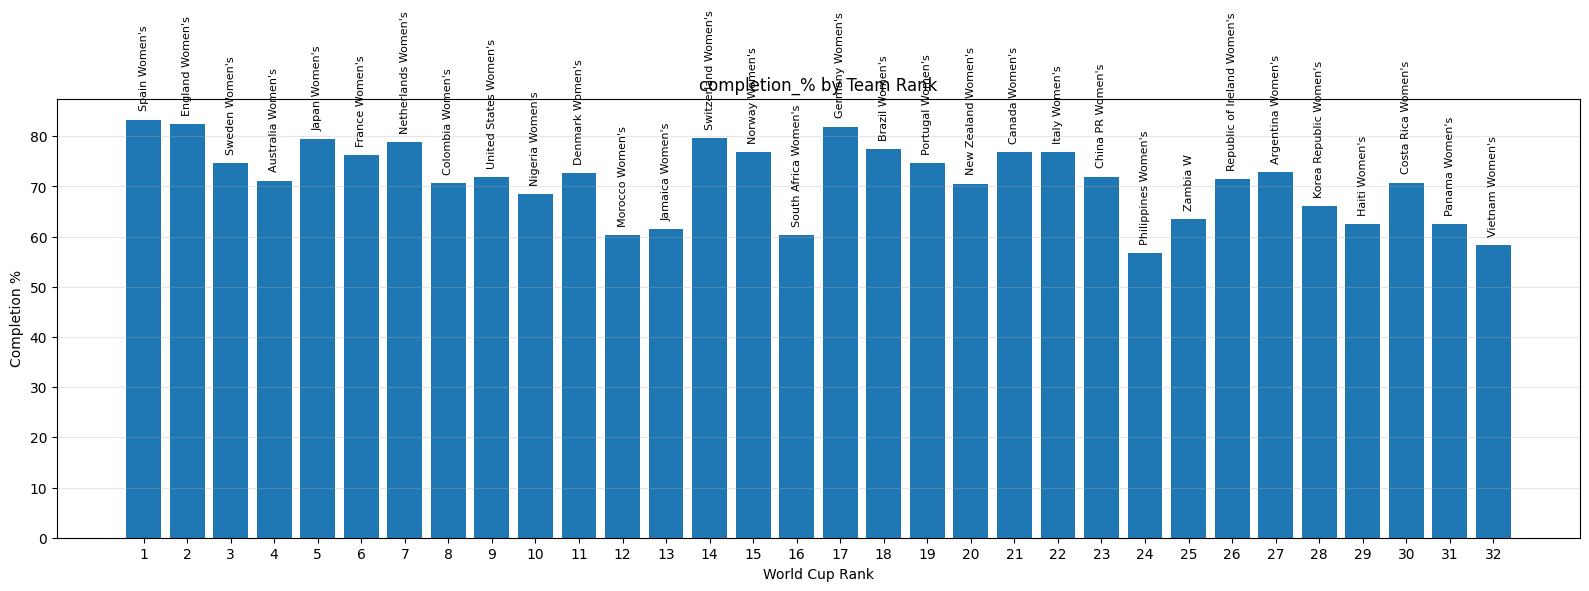

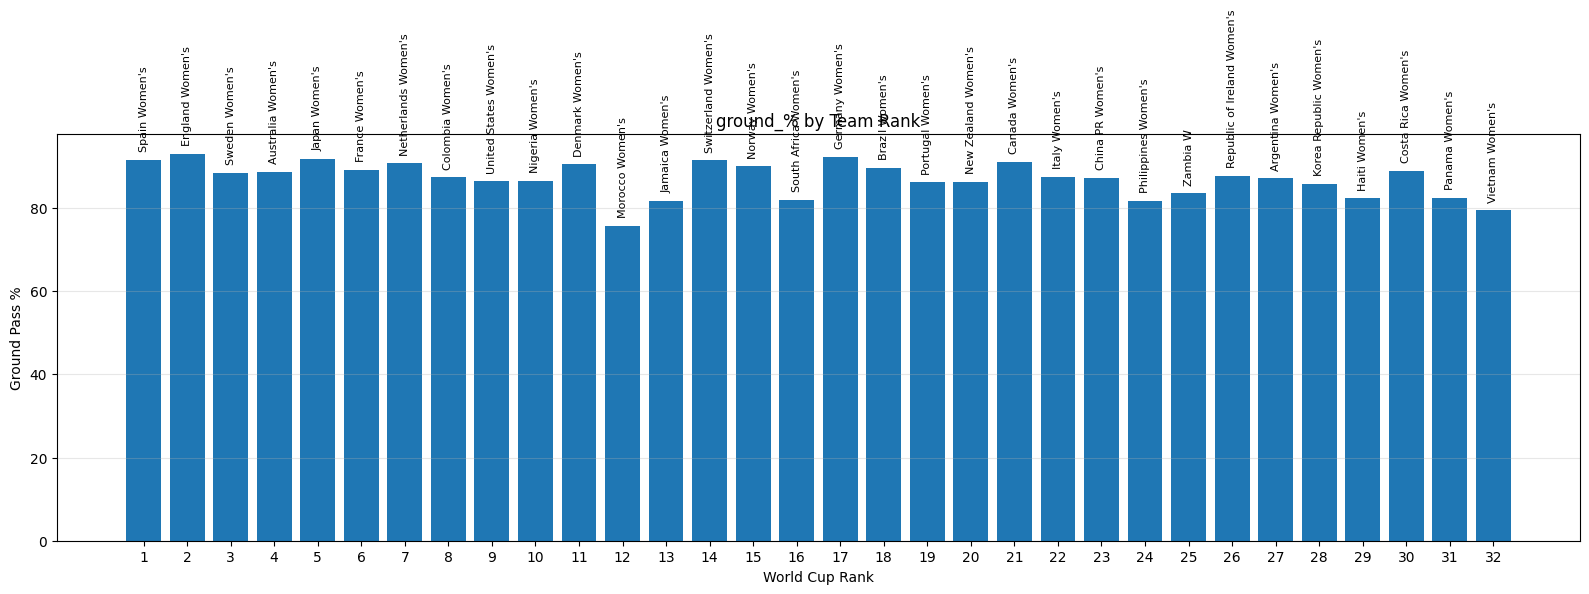

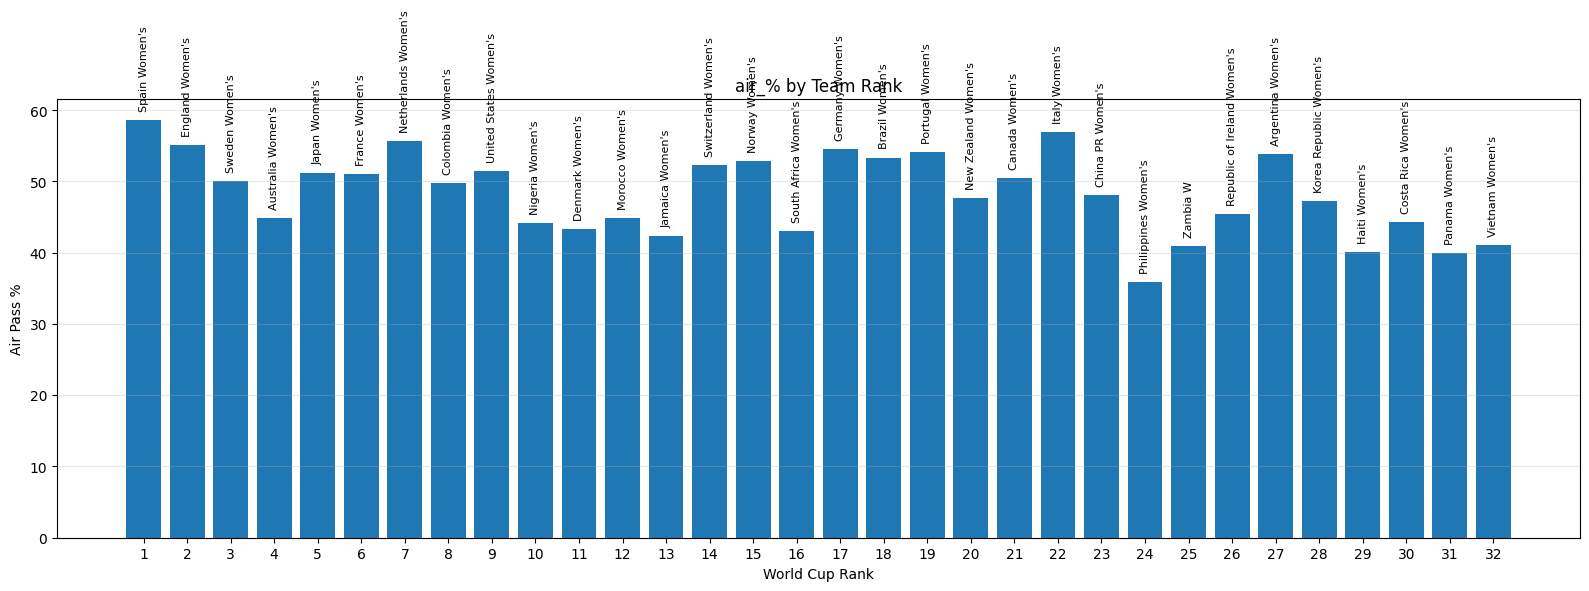

(<Figure size 1600x600 with 1 Axes>,
 <Axes: title={'center': 'air_% by Team Rank'}, xlabel='World Cup Rank', ylabel='Air Pass %'>)

In [115]:
plot_team_metric(df, "completion_%", "Completion %")
plot_team_metric(df, "ground_%", "Ground Pass %")
plot_team_metric(df, "air_%", "Air Pass %")

In [128]:
# table for completion rates per individual team

In [136]:
import pandas as pd

combined_table = df.sort_values("rank").copy()

combined_table = combined_table[
    ["rank", "team", "completion_%", "ground_%", "air_%"]
].reset_index(drop=True)

combined_table = df.sort_values("rank")[
    ["rank", "team", "completion_%", "ground_%", "air_%"]
].rename(columns={
    "rank": "Rank",
    "team": "Team",
    "completion_%": "Overall Pass Completion %",
    "ground_%": "Ground Pass Completion %",
    "air_%": "Air Pass Completion %"
}).reset_index(drop=True)

display(combined_table)

,Rank,Team,Overall Pass Completion %,Ground Pass Completion %,Air Pass Completion %
0,1,Spain Women's,83.296259,91.596866,58.601286
1,2,England Women's,82.448691,93.032385,55.076142
2,3,Sweden Women's,74.671725,88.409091,50.040750
3,4,Australia Women's,71.161893,88.715744,44.943820
4,5,Japan Women's,79.398827,91.864765,51.137725
5,6,France Women's,76.161544,89.196526,51.046025
6,7,Netherlands Women's,78.839590,90.702479,55.734406
7,8,Colombia Women's,70.659898,87.385740,49.771689
8,9,United States Women's,71.814475,86.351706,51.526252
9,10,Nigeria Women's,68.519805,86.561743,44.208809


In [122]:
# scatterplot of 32 teams passing completion by overall, ground, air

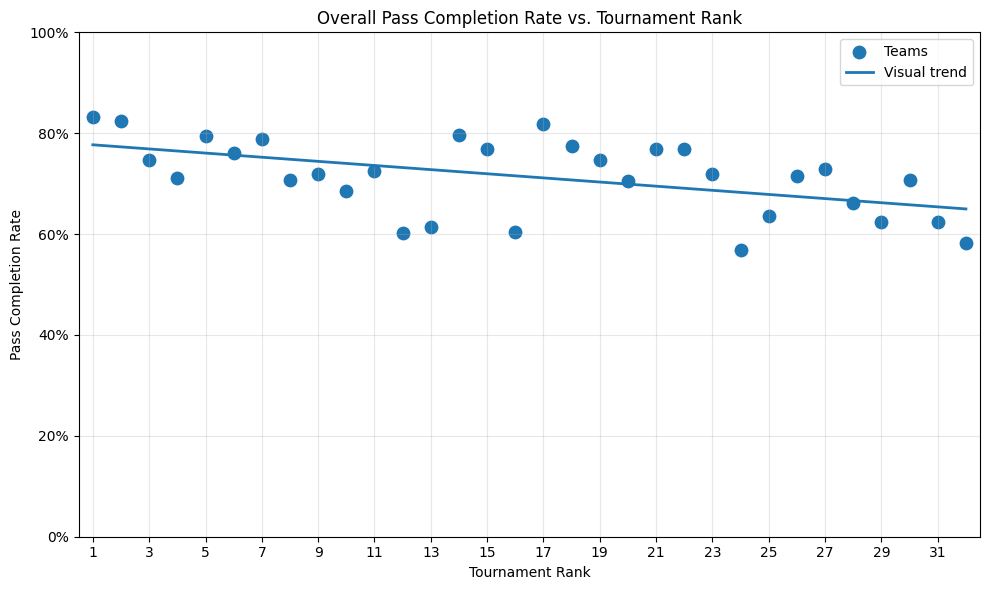

Trend-line slope: -0.410211


In [146]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plot_df = df.dropna(subset=["rank", "completion_%"]).copy()
plot_df = plot_df.sort_values("rank")

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    plot_df["rank"],
    plot_df["completion_%"],
    s=80,
    label="Teams"
)

slope, intercept = np.polyfit(
    plot_df["rank"],
    plot_df["completion_%"],
    1
)

x_line = np.linspace(1, 32, 100)
y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Visual trend"
)

ax.set_xlim(0.5, 32.5)
ax.set_ylim(0, 100)
ax.set_xticks(range(1, 33, 2))
ax.yaxis.set_major_formatter(PercentFormatter(100))

ax.set_xlabel("Tournament Rank")
ax.set_ylabel("Pass Completion Rate")
ax.set_title("Overall Pass Completion Rate vs. Tournament Rank")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Trend-line slope: {slope:.6f}")

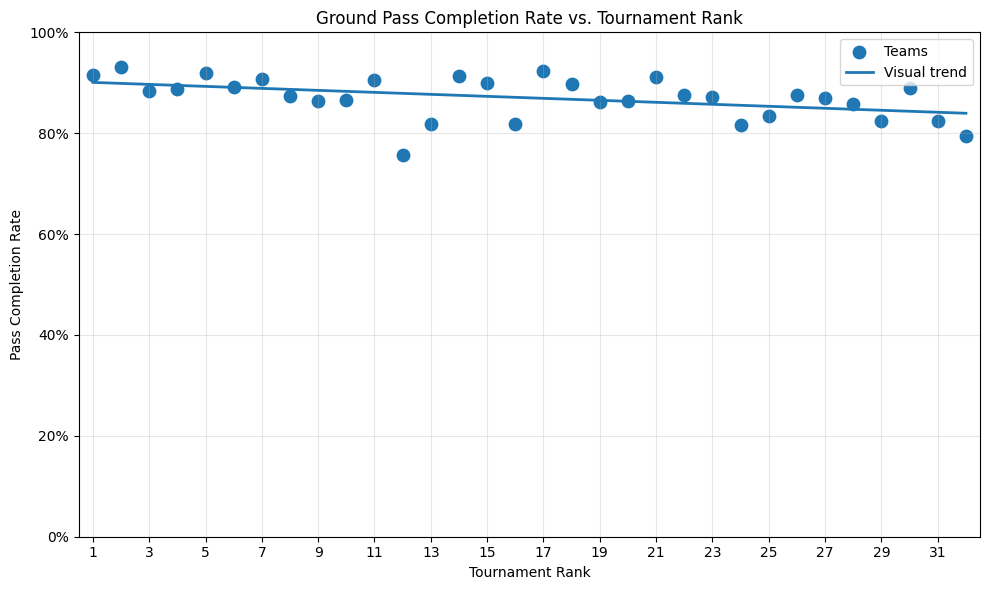

Trend-line slope: -0.197366


In [147]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plot_df = df.dropna(subset=["rank", "ground_%"]).copy()
plot_df = plot_df.sort_values("rank")

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    plot_df["rank"],
    plot_df["ground_%"],
    s=80,
    label="Teams"
)

slope, intercept = np.polyfit(
    plot_df["rank"],
    plot_df["ground_%"],
    1
)

x_line = np.linspace(1, 32, 100)
y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Visual trend"
)

ax.set_xlim(0.5, 32.5)
ax.set_ylim(0, 100)
ax.set_xticks(range(1, 33, 2))
ax.yaxis.set_major_formatter(PercentFormatter(100))

ax.set_xlabel("Tournament Rank")
ax.set_ylabel("Pass Completion Rate")
ax.set_title("Ground Pass Completion Rate vs. Tournament Rank")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Trend-line slope: {slope:.6f}")

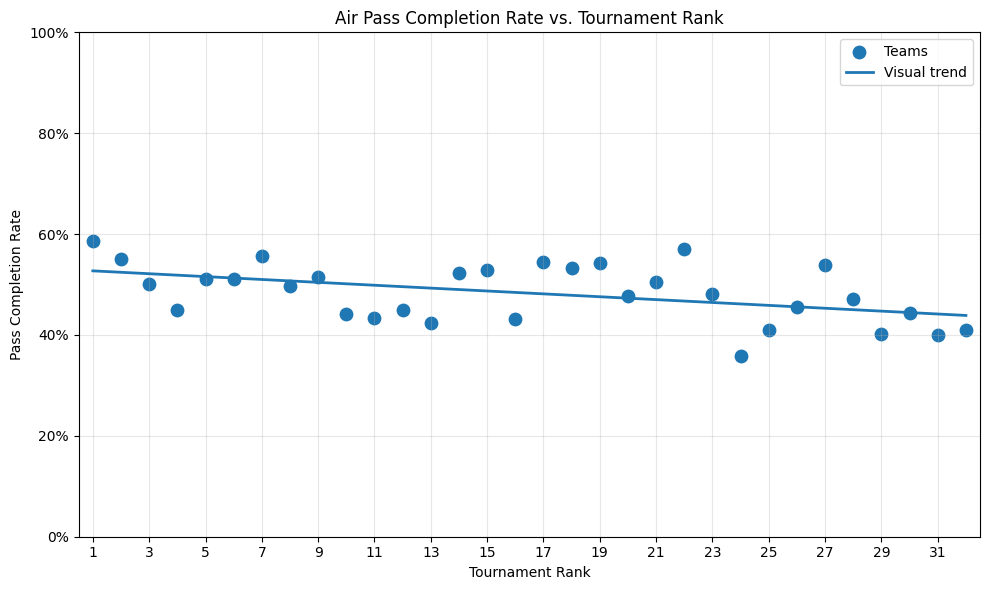

Trend-line slope: -0.285186


In [148]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

plot_df = df.dropna(subset=["rank", "air_%"]).copy()
plot_df = plot_df.sort_values("rank")

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    plot_df["rank"],
    plot_df["air_%"],
    s=80,
    label="Teams"
)

slope, intercept = np.polyfit(
    plot_df["rank"],
    plot_df["air_%"],
    1
)

x_line = np.linspace(1, 32, 100)
y_line = slope * x_line + intercept

ax.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Visual trend"
)

ax.set_xlim(0.5, 32.5)
ax.set_ylim(0, 100)
ax.set_xticks(range(1, 33, 2))
ax.yaxis.set_major_formatter(PercentFormatter(100))

ax.set_xlabel("Tournament Rank")
ax.set_ylabel("Pass Completion Rate")
ax.set_title("Air Pass Completion Rate vs. Tournament Rank")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Trend-line slope: {slope:.6f}")

In [102]:
# spearman correlation + bonferroni correction

In [142]:
from scipy.stats import spearmanr
import pandas as pd

metrics = [
    "completion_%",
    "ground_%",
    "air_%",
]

results = []

for metric in metrics:
    rho, p = spearmanr(df["rank"], df[metric], nan_policy="omit")
    results.append({
        "Metric": metric,
        "Spearman rho": rho,
        "p-value": p
    })

results_df = pd.DataFrame(results)

display(results_df)

,Metric,Spearman rho,p-value
0,completion_%,-0.495601,0.003922
1,ground_%,-0.509164,0.002919
2,air_%,-0.445748,0.010562


In [141]:
import pandas as pd
from statsmodels.stats.multitest import multipletests

results = pd.DataFrame({
    "Metric": ["completion_%", "ground_%", "air_%"],
    "Spearman's rho": [-0.495601, -0.509164, -0.445748],
    "p-value": [0.003922, 0.002919, 0.010562]
})

bonf_reject, bonf_p, _, _ = multipletests(
    results["p-value"],
    method="bonferroni"
)

results["Bonferroni p-value"] = bonf_p

results.round(3)

display(results[["Metric", "Spearman's rho", "Bonferroni p-value"]].round(3))

,Metric,Spearman's rho,Bonferroni p-value
0,completion_%,-0.496,0.012
1,ground_%,-0.509,0.009
2,air_%,-0.446,0.032


In [115]:
# cohen's d -> hedges' g

In [117]:
import numpy as np

def cohens_d(x1, x2):
    x1 = np.array(x1)
    x2 = np.array(x2)

    mean1, mean2 = x1.mean(), x2.mean()
    std1, std2 = x1.std(ddof=1), x2.std(ddof=1)

    pooled_std = np.sqrt((std1**2 + std2**2) / 2)

    return (mean1 - mean2) / pooled_std

In [118]:
top8 = df[df["rank"] <= 8]
bottom8 = df[df["rank"] > 24]

In [121]:
metrics = ["completion_%", "ground_%", "air_%"]

results = []

for m in metrics:
    d = cohens_d(top8[m], bottom8[m])

    results.append({
        "metric": m,
        "cohens_d (Top8 vs Bottom8)": d
    })

pd.DataFrame(results)

,metric,cohens_d (Top8 vs Bottom8)
0,completion_%,2.214119
1,ground_%,2.036820
2,air_%,1.753927


In [123]:
top4 = df[df["rank"] <= 4]
bottom4 = df[df["rank"] > 28]
results = []

for m in metrics:
    d = cohens_d(top4[m], bottom4[m])

    results.append({
        "metric": m,
        "cohens_d (Top4 vs Bottom4)": d
    })

pd.DataFrame(results)

,metric,cohens_d (Top4 vs Bottom4)
0,completion_%,2.575958
1,ground_%,2.202406
2,air_%,2.419421


In [160]:
import numpy as np
import pandas as pd

def hedges_g(x1, x2):
    x1 = np.array(x1)
    x2 = np.array(x2)

    n1, n2 = len(x1), len(x2)
    df = n1 + n2 - 2

    mean1, mean2 = x1.mean(), x2.mean()
    std1, std2 = x1.std(ddof=1), x2.std(ddof=1)

    pooled_std = np.sqrt((std1**2 + std2**2) / 2)

    d = (mean1 - mean2) / pooled_std

    J = 1 - (3 / (4 * df - 1))

    return d * J


metrics = ["completion_%", "ground_%", "air_%"]

results = []

for m in metrics:
    d = cohens_d(top8[m], bottom8[m])
    g = hedges_g(top8[m], bottom8[m])

    results.append({
        "Metric": m,
        "Hedges' g (T8 vs. B8)": g,
    })

results_df = pd.DataFrame(results)

results_df

,Metric,Hedges' g (T8 vs. B8)
0,completion_%,2.093349
1,ground_%,1.925721
2,air_%,1.658259


In [126]:
results = []

for m in metrics:
    d = cohens_d(top4[m], bottom4[m])
    g = hedges_g(top4[m], bottom4[m])

    results.append({
        "Metric": m,
        "Hedges' g (T4 vs B4)": g,
    })

results_df = pd.DataFrame(results)

results_df

,Metric,Hedges' g (T4 vs B4)
0,completion_%,2.239963
1,ground_%,1.915135
2,air_%,2.103844
